# VoiceOfBank — 02 EDA
**Notebook 2 of 7** · Run locally

Explore 30,000 Google Play reviews across 6 UK banks.

**Input:** `data/raw/reviews_raw.csv`
**Output:** Charts + insights to guide modelling decisions


## 1. Setup

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS  = sns.color_palette('muted')
BANKS   = ['Monzo','Starling','Barclays','HSBC','NatWest','Lloyds']
PALETTE = dict(zip(BANKS, sns.color_palette('tab10', 6)))
TRADITIONAL = ['Barclays','HSBC','NatWest','Lloyds']
CHALLENGER  = ['Monzo','Starling']

df = pd.read_csv('../data/raw/reviews_raw.csv', parse_dates=['at'])
df = df.dropna(subset=['content'])
df['review_len'] = df['content'].str.len()
df['year_month'] = df['at'].dt.to_period('M')
df['type'] = df['bank'].apply(
    lambda x: 'Challenger' if x in CHALLENGER else 'Traditional')

print('Shape:', df.shape)
print('Date range:', df['at'].min().date(), '→', df['at'].max().date())
print()
df.head(3)


Shape: (29999, 16)
Date range: 2024-06-13 → 2026-06-02



,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bank,app_id,review_len,year_month,type
0,de2e33fa-8b9f-4d25-b850-ccde652be126,Áine,https://play-lh.googleusercontent.com/a-/ALV-U...,amazing app,5,0,7.27.0,2026-06-02 09:45:48,NaN,NaN,7.27.0,Monzo,co.uk.getmondo,11,2026-06,Challenger
1,8b63c112-adc9-4102-a10d-c5177e111cb2,john ganz,https://play-lh.googleusercontent.com/a-/ALV-U...,love monzo it's so easy to use few people said...,5,0,7.27.0,2026-06-02 08:25:55,NaN,NaN,7.27.0,Monzo,co.uk.getmondo,79,2026-06,Challenger
2,d658f4cd-ed2d-40a4-92be-5f86d3ab9555,shane harte,https://play-lh.googleusercontent.com/a-/ALV-U...,easy to use the app doesn't seem to crash like...,4,0,7.28.0,2026-06-01 20:49:59,NaN,NaN,7.28.0,Monzo,co.uk.getmondo,71,2026-06,Challenger


In [3]:
df.sample(10)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bank,app_id,review_len,year_month,type
5866,a3641258-a56d-4391-b52e-a1103ecc3dde,val val.,https://play-lh.googleusercontent.com/a/ACg8oc...,"very straightforward and easy to use, love it ...",5,0,4.34.1.130536,2026-02-06 12:19:20,"Hey there,\n\nThanks for your wonderful review...",2026-02-08 16:39:50,4.34.1.130536,Starling,com.starlingbank.android,86,2026-02,Challenger
14325,898d7f7a-4cf6-4cfa-9901-c1275057f633,koj khan,https://play-lh.googleusercontent.com/a/ACg8oc...,keeps crashing,1,0,8.19.0,2026-02-27 06:32:35,NaN,NaN,8.19.0,Barclays,com.barclays.android.barclaysmobilebanking,14,2026-02,Traditional
29415,b28db6e7-1fa9-4e1e-a4bf-266532a4621e,Clive Turner,https://play-lh.googleusercontent.com/a/ACg8oc...,easy to use but options keep moving location,5,0,178.05,2026-02-01 11:56:11,Thank you for your feedback. We appreciate you...,2026-02-03 10:13:43,178.05,Lloyds,com.grppl.android.shell.CMBlloydsTSB73,44,2026-02,Traditional
8381,3a59b56f-aa4c-4171-a90b-7d368009505b,Sally Blizard,https://play-lh.googleusercontent.com/a/ACg8oc...,really easy to use. great company.,5,0,4.1.0.116935,2025-06-05 06:44:48,NaN,NaN,4.1.0.116935,Starling,com.starlingbank.android,34,2025-06,Challenger
6306,0011cb25-3584-4f0c-93ed-9a9b6cb24715,Fatih Segmen,https://play-lh.googleusercontent.com/a/ACg8oc...,good but sometimes unnecessary processes,4,0,4.28.1.127921,2025-12-07 22:04:32,"Hi Fatih, thanks for taking the time to review...",2025-12-08 08:58:50,4.28.1.127921,Starling,com.starlingbank.android,40,2025-12,Challenger
29936,14c39252-f571-4723-954a-7ea18518434e,ajuko robin,https://play-lh.googleusercontent.com/a-/ALV-U...,So easy to use ilove this app,5,0,178.05,2026-01-15 20:56:57,Thank you! We’re glad the app is easy to use a...,2026-01-19 09:52:02,178.05,Lloyds,com.grppl.android.shell.CMBlloydsTSB73,29,2026-01,Traditional
11319,368e0daf-4511-4857-a453-a2ac18d96a6e,Najma Islam,https://play-lh.googleusercontent.com/a-/ALV-U...,Fantastic! The people on the phone are pretty ...,5,0,8.21.0,2026-04-30 02:57:20,NaN,NaN,8.21.0,Barclays,com.barclays.android.barclaysmobilebanking,150,2026-04,Traditional
24300,9edb2318-ab33-4217-955d-f1ea8e6c7521,julie Ingram,https://play-lh.googleusercontent.com/a/ACg8oc...,❤️ love banking with natwest. Been with you gu...,5,0,07.54.0000.3.0,2025-05-25 09:22:50,NaN,NaN,07.54.0000.3.0,NatWest,com.rbs.mobile.android.natwest,57,2025-05,Traditional
24398,789ebfc9-6992-4bd2-b8b6-0f8e1f7fcc26,Piers Evelegh,https://play-lh.googleusercontent.com/a/ACg8oc...,rubbish,1,0,07.53.0000.3.0,2025-05-17 18:03:32,"Oh sorry about that, let's get you in touch wi...",2025-05-19 13:39:15,07.53.0000.3.0,NatWest,com.rbs.mobile.android.natwest,7,2025-05,Traditional
12235,6b11cc2e-9a59-464d-a04d-28a2be5c51dc,Nicky Garner,https://play-lh.googleusercontent.com/a/ACg8oc...,Easy to pay. A reminder that it could be a sca...,5,0,8.20.1,2026-04-06 18:55:45,NaN,NaN,8.20.1,Barclays,com.barclays.android.barclaysmobilebanking,104,2026-04,Traditional


In [8]:
df['bank'].sample(7)

5653     Starling
16067        HSBC
22492     NatWest
11964    Barclays
4673        Monzo
28838      Lloyds
26740      Lloyds
Name: bank, dtype: object

## 2. Rating Distributions

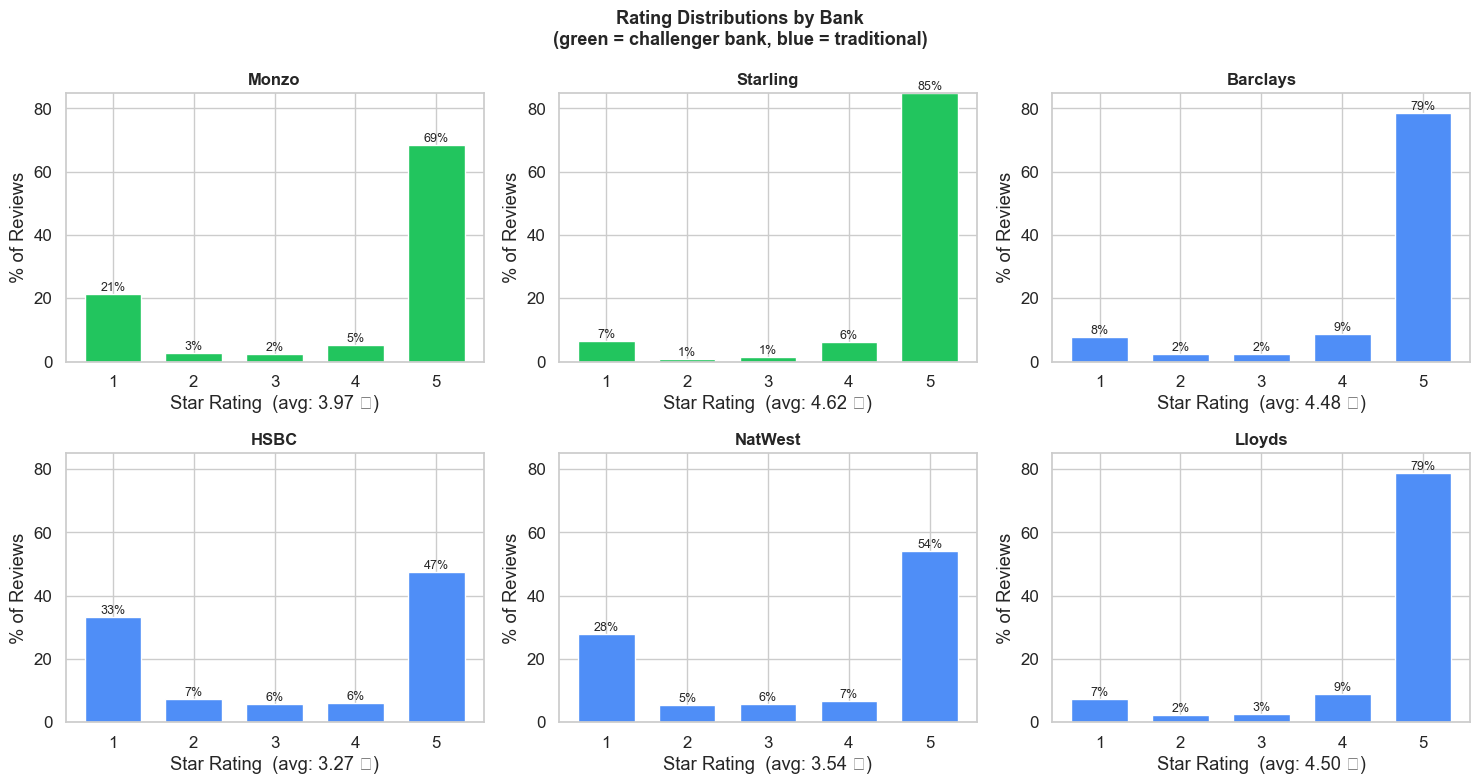

Average ratings:
bank
Starling    4.62
Lloyds      4.50
Barclays    4.48
Monzo       3.97
NatWest     3.54
HSBC        3.27


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, bank in enumerate(BANKS):
    sub = df[df['bank']==bank]
    counts = sub['score'].value_counts().sort_index()
    pcts   = counts / len(sub) * 100
    color  = '#22c55e' if bank in CHALLENGER else '#4f8ef7'

    axes[i].bar(counts.index, pcts.values, color=color,
                edgecolor='white', width=0.7)
    axes[i].set_title(f'{bank}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Star Rating')
    axes[i].set_ylabel('% of Reviews')
    axes[i].set_xticks([1,2,3,4,5])
    axes[i].set_ylim(0, 85)
    for j, (score, pct) in enumerate(zip(counts.index, pcts.values)):
        axes[i].text(score, pct+1, f'{pct:.0f}%', ha='center', fontsize=9)

    avg = sub['score'].mean()
    axes[i].set_xlabel(f'Star Rating  (avg: {avg:.2f} ⭐)')

plt.suptitle('Rating Distributions by Bank\n'
             '(green = challenger bank, blue = traditional)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Average ratings:')
print(df.groupby('bank')['score'].mean().sort_values(ascending=False).round(2).to_string())


## 3. Challenger vs Traditional — Side by Side

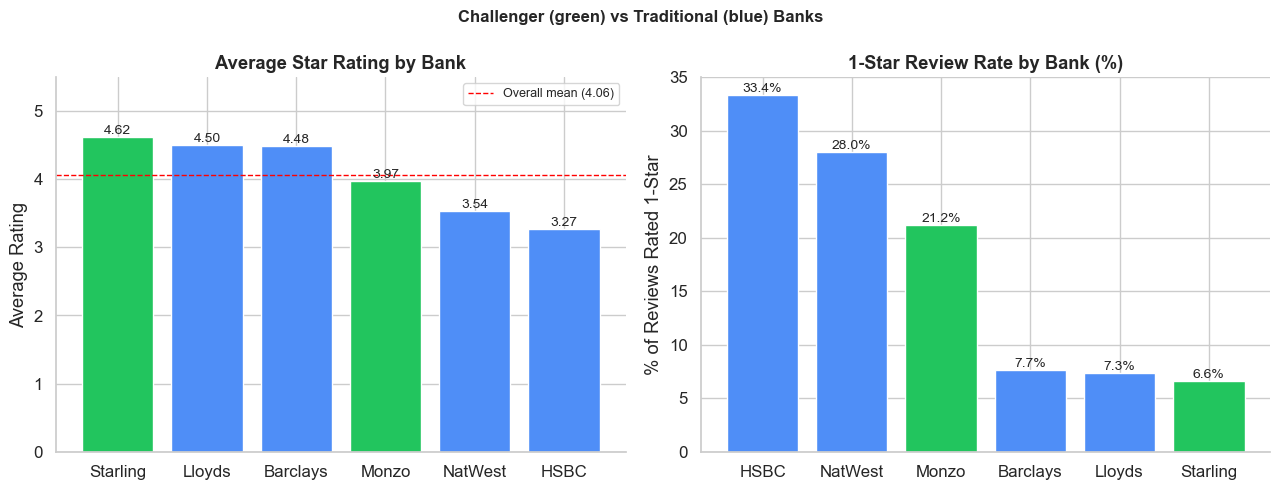

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Average rating
avg_rating = df.groupby('bank')['score'].mean().sort_values(ascending=False)
colors = ['#22c55e' if b in CHALLENGER else '#4f8ef7' for b in avg_rating.index]
axes[0].bar(avg_rating.index, avg_rating.values, color=colors, edgecolor='white')
axes[0].set_title('Average Star Rating by Bank', fontweight='bold')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(0, 5.5)
axes[0].axhline(df['score'].mean(), color='red', linestyle='--',
                linewidth=1, label=f'Overall mean ({df["score"].mean():.2f})')
axes[0].legend(fontsize=9)
for j, (bank, val) in enumerate(avg_rating.items()):
    axes[0].text(j, val+0.05, f'{val:.2f}', ha='center', fontsize=10)

# 1-star rate
one_star = df.groupby('bank').apply(
    lambda x: (x['score']==1).mean()*100).sort_values(ascending=False)
colors2 = ['#22c55e' if b in CHALLENGER else '#4f8ef7' for b in one_star.index]
axes[1].bar(one_star.index, one_star.values, color=colors2, edgecolor='white')
axes[1].set_title('1-Star Review Rate by Bank (%)', fontweight='bold')
axes[1].set_ylabel('% of Reviews Rated 1-Star')
for j, (bank, val) in enumerate(one_star.items()):
    axes[1].text(j, val+0.3, f'{val:.1f}%', ha='center', fontsize=10)

sns.despine()
plt.suptitle('Challenger (green) vs Traditional (blue) Banks',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Review Volume Over Time

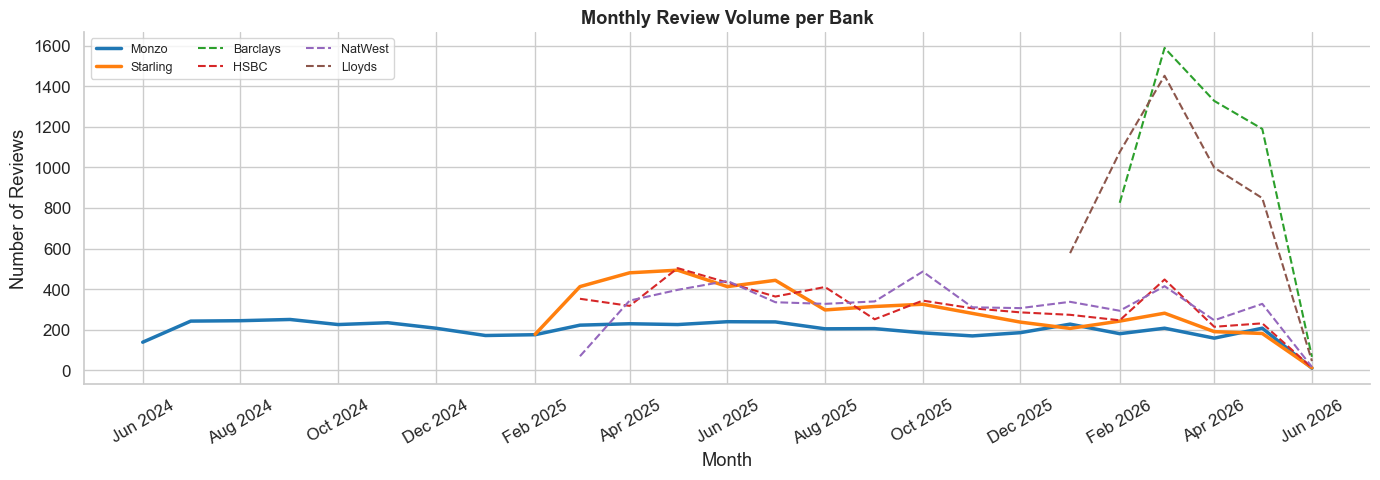

In [10]:
monthly = df.groupby(['year_month','bank']).size().reset_index(name='count')
monthly['date'] = monthly['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
for bank in BANKS:
    sub = monthly[monthly['bank']==bank]
    lw  = 2.5 if bank in CHALLENGER else 1.5
    ls  = '-'  if bank in CHALLENGER else '--'
    ax.plot(sub['date'], sub['count'], label=bank,
            color=PALETTE[bank], linewidth=lw, linestyle=ls)

ax.set_xlabel('Month')
ax.set_ylabel('Number of Reviews')
ax.set_title('Monthly Review Volume per Bank', fontweight='bold')
ax.legend(ncol=3, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.show()


## 5. Monthly Average Rating Over Time

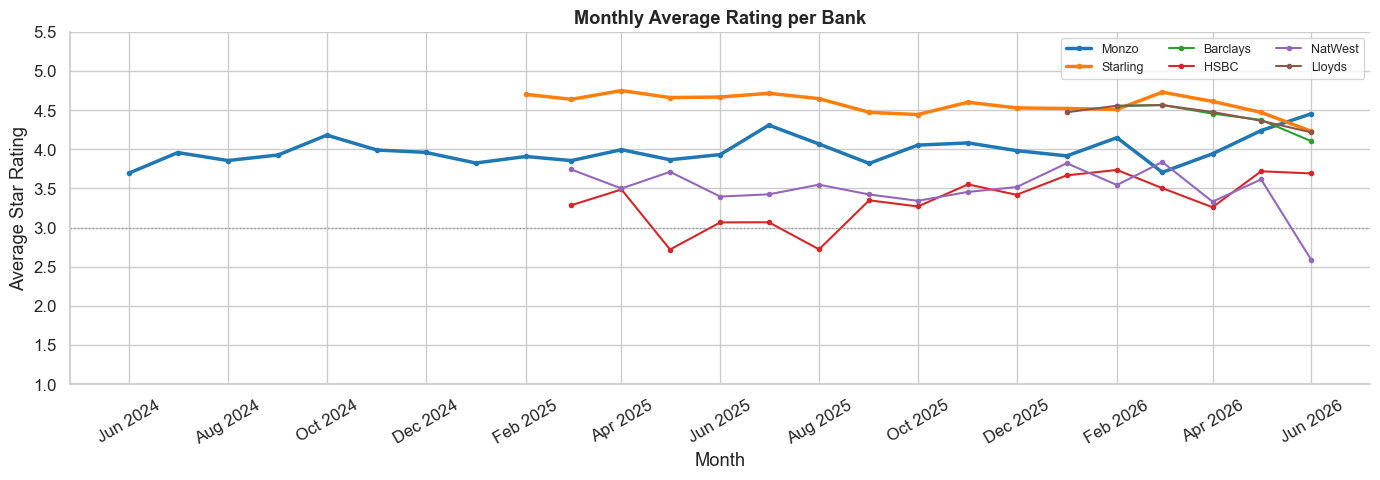

Key observation: Look for rating dips — these often correspond
to app outages, policy changes, or feature removals.


In [11]:
monthly_rating = df.groupby(['year_month','bank'])['score'].mean().reset_index()
monthly_rating['date'] = monthly_rating['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
for bank in BANKS:
    sub = monthly_rating[monthly_rating['bank']==bank]
    lw  = 2.5 if bank in CHALLENGER else 1.5
    ax.plot(sub['date'], sub['score'], label=bank,
            color=PALETTE[bank], linewidth=lw, marker='o', markersize=3)

ax.set_xlabel('Month')
ax.set_ylabel('Average Star Rating')
ax.set_ylim(1, 5.5)
ax.set_title('Monthly Average Rating per Bank', fontweight='bold')
ax.axhline(3, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.legend(ncol=3, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

print('Key observation: Look for rating dips — these often correspond')
print('to app outages, policy changes, or feature removals.')


## 6. Review Length Analysis

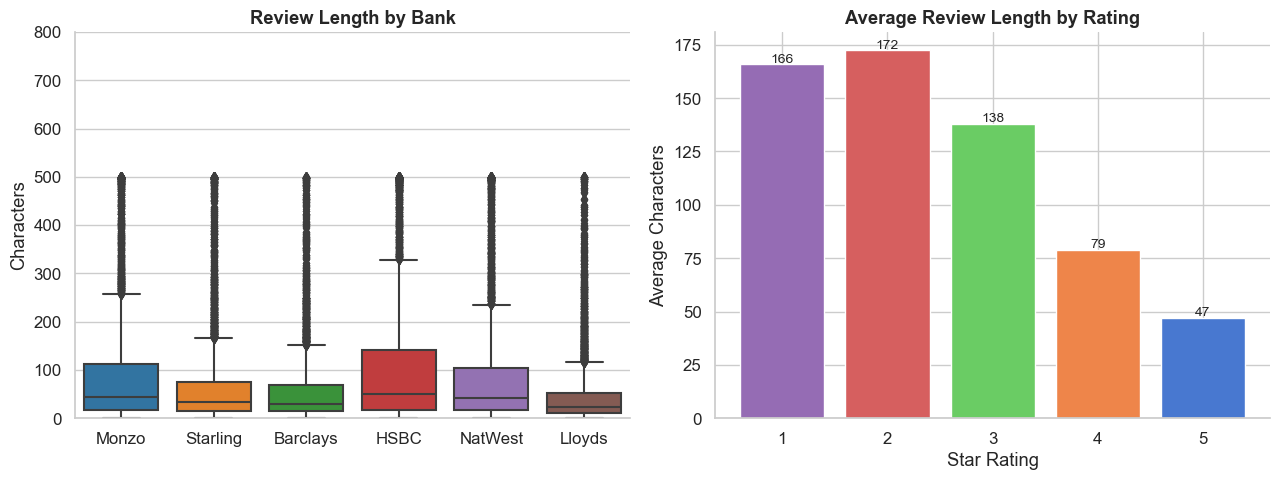

Key observation: 1-star reviews tend to be longer — angry customers
write more. This is useful for complaint analysis.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Length by bank
sns.boxplot(data=df, x='bank', y='review_len', order=BANKS,
            palette=[PALETTE[b] for b in BANKS], ax=axes[0])
axes[0].set_title('Review Length by Bank', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Characters')
axes[0].set_ylim(0, 800)

# Length by rating
avg_len_by_rating = df.groupby('score')['review_len'].mean()
axes[1].bar(avg_len_by_rating.index, avg_len_by_rating.values,
            color=[COLORS[4],COLORS[3],COLORS[2],COLORS[1],COLORS[0]],
            edgecolor='white')
axes[1].set_title('Average Review Length by Rating', fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Average Characters')
for j, (score, val) in enumerate(avg_len_by_rating.items()):
    axes[1].text(score, val+1, f'{val:.0f}', ha='center', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

print('Key observation: 1-star reviews tend to be longer — angry customers')
print('write more. This is useful for complaint analysis.')


## 7. Most Common Words — Complaint Reviews (1-2 Stars)

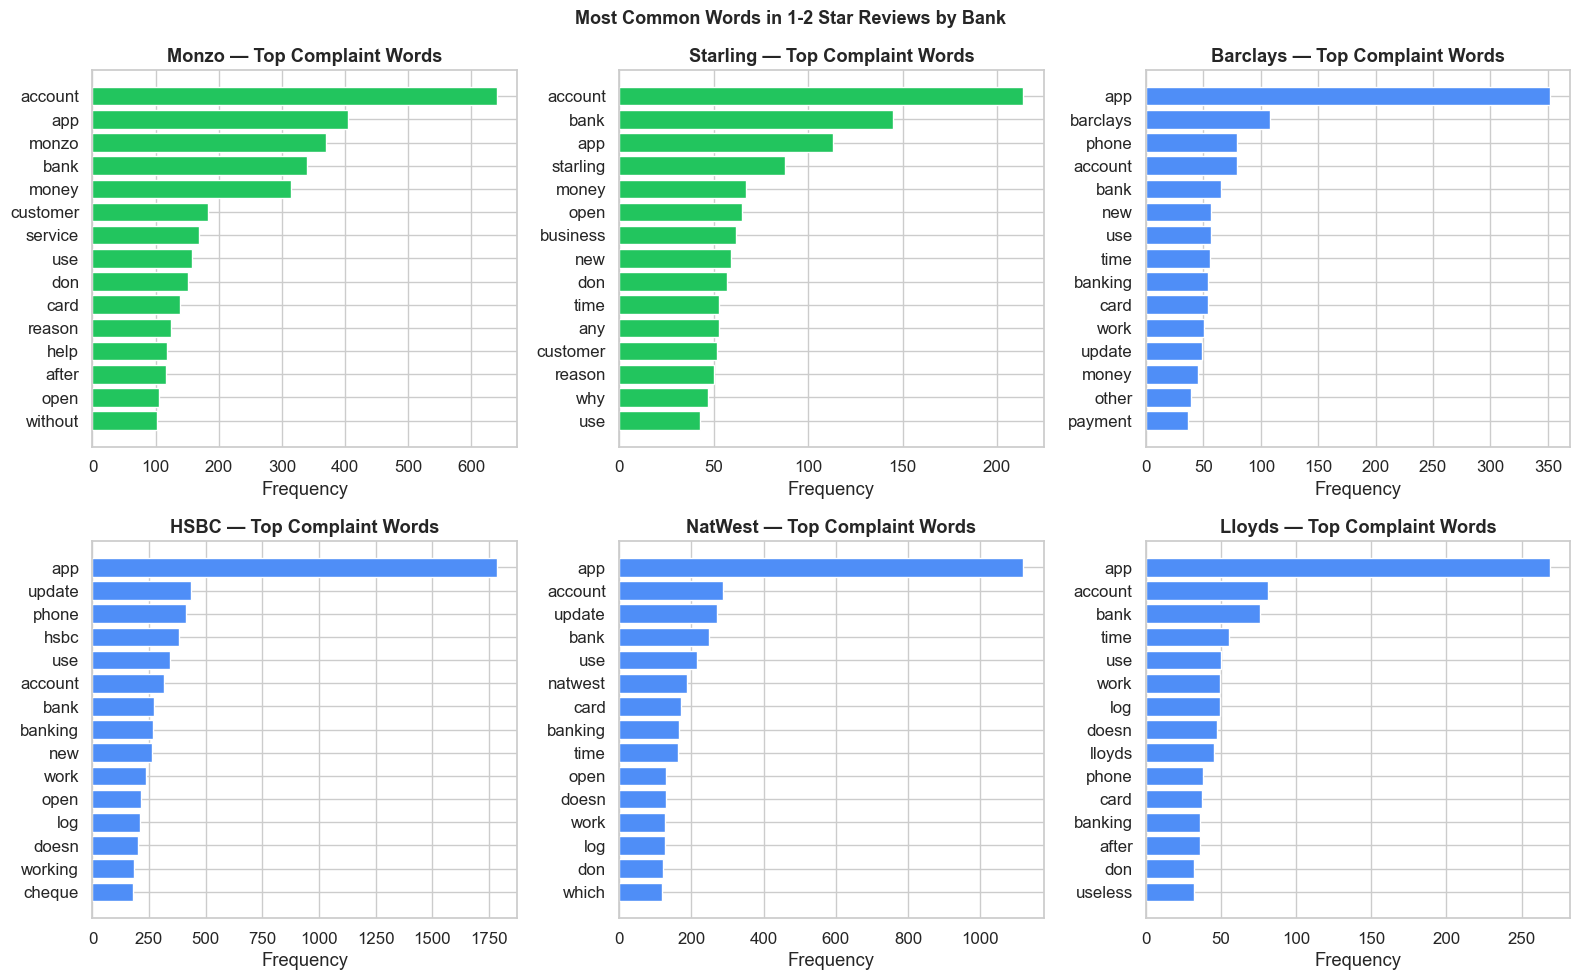

In [13]:
from collections import Counter
import re

STOPWORDS = set([
    'the','a','an','and','or','but','in','on','at','to','for',
    'of','with','is','it','i','my','me','they','this','that',
    'was','have','has','had','be','been','are','as','by','not',
    'from','so','do','did','its','we','you','your','our','their',
    'up','out','can','cant','will','would','get','got','im','ive',
    'just','been','very','still','even','now','when','all','more',
    'no','if','about','he','she','his','her','them','then','than',
])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, bank in enumerate(BANKS):
    complaints = df[(df['bank']==bank) & (df['score']<=2)]['content']
    words = []
    for text in complaints:
        tokens = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
        words.extend([w for w in tokens if w not in STOPWORDS])

    top_words = Counter(words).most_common(15)
    words_list = [w for w, c in top_words]
    counts_list = [c for w, c in top_words]

    color = '#22c55e' if bank in CHALLENGER else '#4f8ef7'
    axes[i].barh(words_list[::-1], counts_list[::-1],
                 color=color, edgecolor='white')
    axes[i].set_title(f'{bank} — Top Complaint Words', fontweight='bold')
    axes[i].set_xlabel('Frequency')

plt.suptitle('Most Common Words in 1-2 Star Reviews by Bank',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Bank Reply Rate

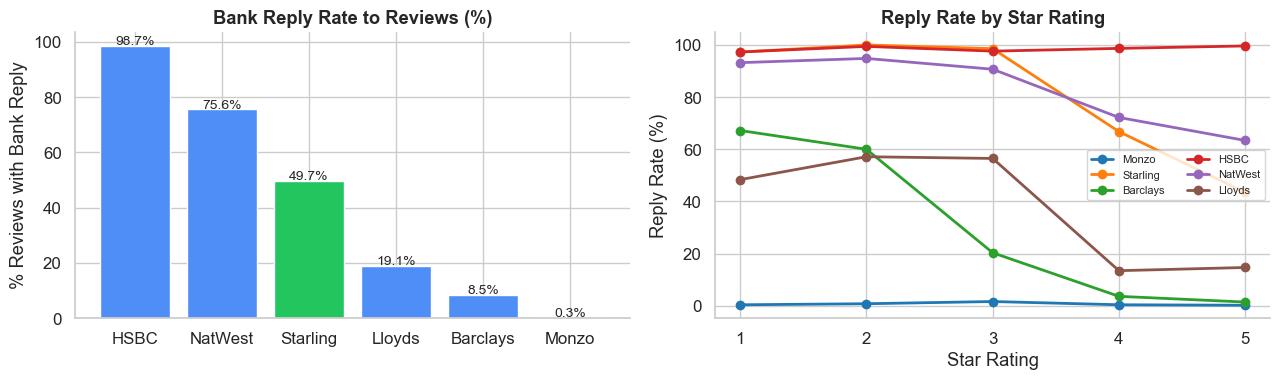

Key observation: Do banks reply more to 1-star reviews?
High reply rate to complaints suggests active customer service.


In [14]:
df['has_reply'] = df['replyContent'].notna()

reply_rate = df.groupby('bank')['has_reply'].mean().mul(100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['#22c55e' if b in CHALLENGER else '#4f8ef7' for b in reply_rate.index]
axes[0].bar(reply_rate.index, reply_rate.values, color=colors, edgecolor='white')
axes[0].set_title('Bank Reply Rate to Reviews (%)', fontweight='bold')
axes[0].set_ylabel('% Reviews with Bank Reply')
for j, (bank, val) in enumerate(reply_rate.items()):
    axes[0].text(j, val+0.3, f'{val:.1f}%', ha='center', fontsize=10)

# Reply rate by star rating per bank
reply_by_score = df.groupby(['bank','score'])['has_reply'].mean().mul(100).reset_index()
for bank in BANKS:
    sub = reply_by_score[reply_by_score['bank']==bank]
    axes[1].plot(sub['score'], sub['has_reply'], label=bank,
                 color=PALETTE[bank], marker='o', linewidth=2)

axes[1].set_title('Reply Rate by Star Rating', fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Reply Rate (%)')
axes[1].set_xticks([1,2,3,4,5])
axes[1].legend(ncol=2, fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()

print('Key observation: Do banks reply more to 1-star reviews?')
print('High reply rate to complaints suggests active customer service.')


## 9. EDA Summary — Key Findings

In [15]:
print('='*60)
print('EDA SUMMARY — KEY FINDINGS')
print('='*60)
print()

avg = df.groupby('bank')['score'].mean().sort_values(ascending=False)
one_star = df.groupby('bank').apply(lambda x: (x['score']==1).mean()*100)
avg_len  = df.groupby('bank')['review_len'].mean()
reply    = df.groupby('bank')['has_reply'].mean().mul(100)

summary = pd.DataFrame({
    'Avg Rating'   : avg.round(2),
    '1-Star Rate %': one_star.round(1),
    'Avg Length'   : avg_len.round(0),
    'Reply Rate %' : reply.round(1),
    'Type'         : ['Challenger' if b in CHALLENGER else 'Traditional'
                      for b in avg.index]
}).sort_values('Avg Rating', ascending=False)

print(summary.to_string())
print()
print('Total reviews  :', len(df))
print('Date range     :', df["at"].min().date(), '→', df["at"].max().date())
print('Complaint rate :', f'{(df["score"]<=2).mean()*100:.1f}%  (1-2 star reviews)')
print()
print('Next: 03_preprocessing.ipynb')


EDA SUMMARY — KEY FINDINGS

          Avg Rating  1-Star Rate %  Avg Length  Reply Rate %         Type
bank                                                                      
Starling        4.62            6.6        70.0          49.7  Traditional
Lloyds          4.50            7.3        51.0          19.1  Traditional
Barclays        4.48            7.7        62.0           8.5   Challenger
Monzo           3.97           21.2        90.0           0.3   Challenger
NatWest         3.54           28.0        87.0          75.6  Traditional
HSBC            3.27           33.4       104.0          98.7  Traditional

Total reviews  : 29999
Date range     : 2024-06-13 → 2026-06-02
Complaint rate : 20.8%  (1-2 star reviews)

Next: 03_preprocessing.ipynb
